In [1]:
import hail as hl
hl.init(master="local[6]", spark_conf={"spark.driver.memory": "9g"})

Loading BokehJS ...

Running on Apache Spark version 3.5.6
SparkUI available at http://e09e4099080e:4040
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.134-952ae203dbbe
LOGGING: writing to /work/hail-20250909-1127-0.2.134-952ae203dbbe.log


2025-09-09 11:27:44.415 Hail: WARN: cols(): Resulting column table is sorted by 'col_key'.
    To preserve matrix table column order, first unkey columns with 'key_cols_by()'


In [2]:
# =============================================================================
# source / inputs / outputs
# =============================================================================


# ------------------- source ---------------------------------------------------
vds_prefix = "s3://precise-scratch/goypav/1KG/VDS/"
workdir    = vds_prefix + "pca_work/"

# ------------------- inputs ---------------------------------------------------
mt_with_pcs_uri                 = workdir + "1000genomes.n3205.splitmulti.vbi.pca.mt"

# ------------------- outputs --------------------------------------------------


In [3]:
# load and check
mt = hl.read_matrix_table(mt_with_pcs_uri)
mt.describe()

----------------------------------------
Global fields:
    'pca_eigenvalues': array<float64>
----------------------------------------
Column fields:
    's': str
    'sample_info': struct {
        npmid: str, 
        sex: str, 
        pid: str, 
        population_code: str, 
        population_name: str, 
        superpopulation_code: str, 
        superpopulation_name: str, 
        data_collections: array<str>
    }
    'pca': struct {
        PC1: float64, 
        PC2: float64, 
        PC3: float64, 
        PC4: float64, 
        PC5: float64
    }
----------------------------------------
Row fields:
    'locus': locus<GRCh38>
    'alleles': array<str>
    'rsid': str
    'a_index': int32
    'was_split': bool
----------------------------------------
Entry fields:
    'ICNT': array<int32>
    'DP': int32
    'SPL': array<int32>
    'GQ': int32
    'MIN_DP': int32
    'GT': call
    'SQ': float64
    'SB': array<int32>
    'F2R1': array<int32>
    'GP': array<float64>
    'PR

In [4]:
print(f"    reload final MT with PCs: {mt_with_pcs_uri}")
print(f"    n_samples:  {mt.count_cols():,}")
print(f"    n_variants: {mt.count_rows():,}")
print("    globals now include: pca_eigenvalues")

    reload final MT with PCs: s3://precise-scratch/goypav/1KG/VDS/pca_work/1000genomes.n3205.splitmulti.vbi.pca.mt
    n_samples:  3,205
    n_variants: 99,774
    globals now include: pca_eigenvalues


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
# eigenvalues
eigs = hl.eval(mt.pca_eigenvalues)
eigs = np.array(eigs, dtype=float)

# columns table
cols = mt.cols().key_by()  # unkey to avoid key-field protection

cols = cols.select(
    sample_id = cols.s,
    PC1 = cols.pca.PC1,
    PC2 = cols.pca.PC2,
    population = cols.sample_info.population_name,
    superpop   = cols.sample_info.superpopulation_name,
)

# to pandas
df = cols.to_pandas()
print(df.head())
print("n samples:", len(df))
print("have eigenvalues:", eigs.shape, "→ first 5:", eigs[:5])

# --- compute labels for plotting ---
pve = eigs / eigs.sum() if eigs.size else np.array([])
pc1_lbl = f"PC1 ({pve[0]*100:.2f}%)" if pve.size > 0 else "PC1"
pc2_lbl = f"PC2 ({pve[1]*100:.2f}%)" if pve.size > 1 else "PC2"


  sample_id       PC1       PC2 population           superpop
0   HG00096 -0.179924 -0.274758    British  European Ancestry
1   HG00097  -0.17828 -0.277266    British  European Ancestry
2   HG00099 -0.185041 -0.279253    British  European Ancestry
3   HG00100 -0.177562 -0.272973    British  European Ancestry
4   HG00101 -0.183808 -0.268112    British  European Ancestry
n samples: 3205
have eigenvalues: (5,) → first 5: [314.96214859 136.29505583  39.09949393  30.29224037   4.93462582]


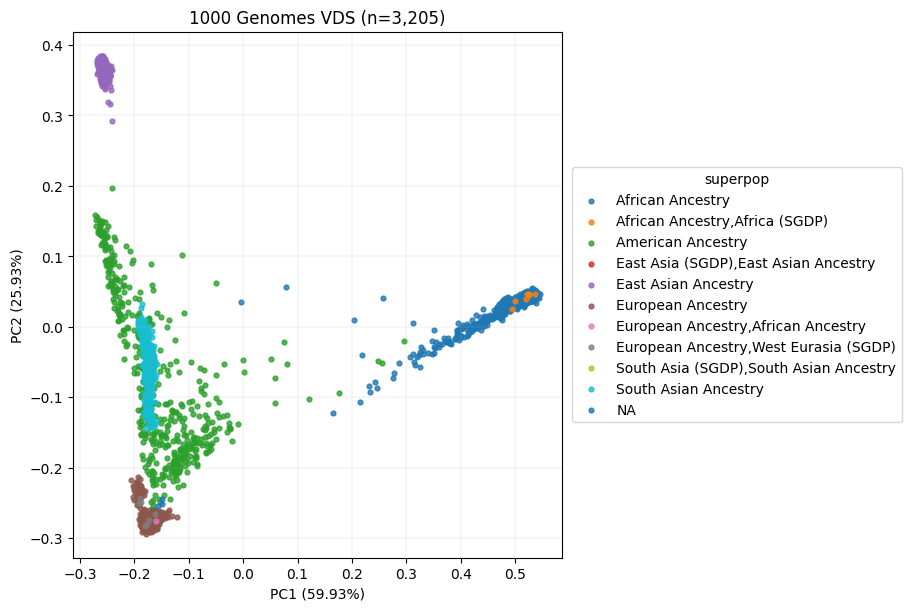

In [7]:
group_col = "superpop"   # or "population" or None
plt.figure(figsize=(9,6), constrained_layout=True)

if group_col is None:
    plt.scatter(df["PC1"], df["PC2"], s=10, alpha=0.7)
else:
    for name, dfg in df.groupby(group_col, dropna=False):
        label = str(name) if pd.notna(name) else "NA"
        plt.scatter(dfg["PC1"], dfg["PC2"], s=12, alpha=0.8, label=label)

plt.xlabel(pc1_lbl)
plt.ylabel(pc2_lbl)

n_samples = len(df)
plt.title(f"1000 Genomes VDS (n={n_samples:,})")

if group_col:
    plt.legend(title=group_col, loc="center left",
               bbox_to_anchor=(1.02, 0.5), frameon=True, borderaxespad=0.0)

plt.margins(x=0.05, y=0.05)
plt.grid(True, linewidth=0.3, alpha=0.5)
# plt.savefig("pc1_pc2_scatter.png", dpi=300)
plt.show()


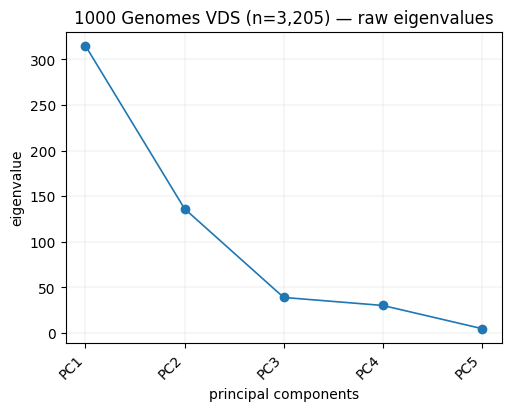

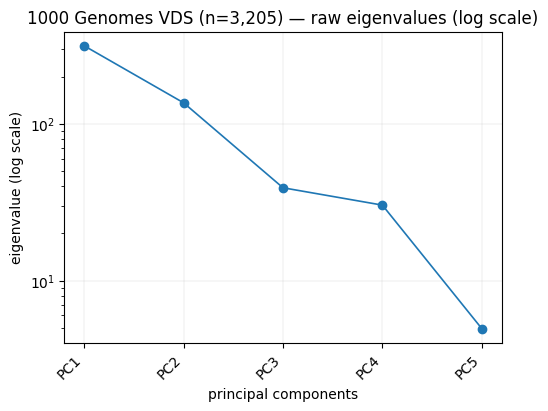

In [8]:
if eigs.size:
    k = len(eigs)
    pcs = [f"PC{i}" for i in range(1, k+1)]
    n_samples = len(df)

    # raw eigenvalues line plot
    plt.figure(figsize=(5,4), constrained_layout=True)
    plt.plot(np.arange(1, k+1), eigs, marker="o", linewidth=1.2)
    plt.xticks(np.arange(1, k+1), pcs, rotation=45, ha="right")
    plt.xlabel("principal components")
    plt.ylabel("eigenvalue")
    plt.title(f"1000 Genomes VDS (n={n_samples:,}) — raw eigenvalues")
    plt.grid(True, linewidth=0.3, alpha=0.5)
    # plt.savefig("pca_eigenvalues_line.png", dpi=300)
    plt.show()

    # log-scale version
    plt.figure(figsize=(5,4), constrained_layout=True)
    plt.plot(np.arange(1, k+1), eigs, marker="o", linewidth=1.2)
    plt.yscale("log")
    plt.xticks(np.arange(1, k+1), pcs, rotation=45, ha="right")
    plt.xlabel("principal components")
    plt.ylabel("eigenvalue (log scale)")
    plt.title(f"1000 Genomes VDS (n={n_samples:,}) — raw eigenvalues (log scale)")
    plt.grid(True, linewidth=0.3, alpha=0.5)
    # plt.savefig("pca_eigenvalues_line_log.png", dpi=300)
    plt.show()


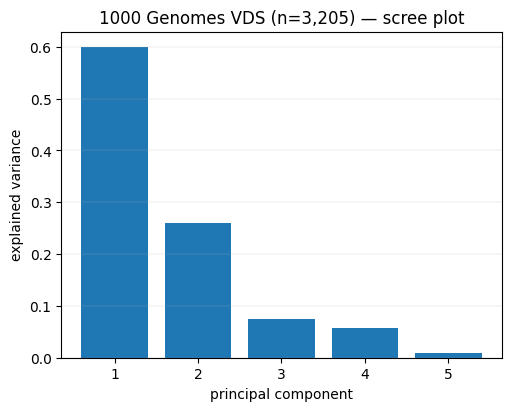

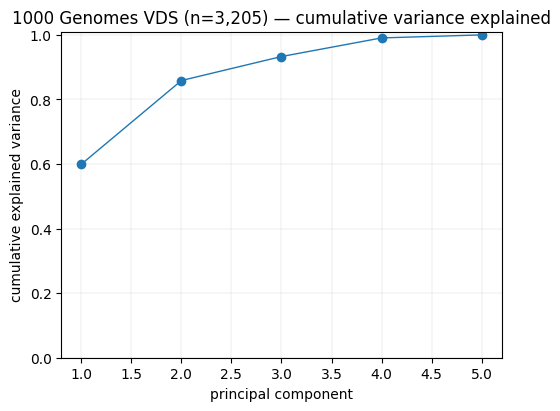

In [9]:
if eigs.size:
    pve = eigs / eigs.sum()
    cum = pve.cumsum()
    k = len(pve)
    n_samples = len(df)

    # scree
    plt.figure(figsize=(5,4), constrained_layout=True)
    plt.bar(np.arange(1, k+1), pve)
    plt.xlabel("principal component")
    plt.ylabel("explained variance")
    plt.title(f"1000 Genomes VDS (n={n_samples:,}) — scree plot")
    plt.xticks(np.arange(1, min(20, k)+1))
    plt.grid(axis="y", linewidth=0.3, alpha=0.5)
    # plt.savefig("pca_scree.png", dpi=300)
    plt.show()

    # cumulative
    plt.figure(figsize=(5,4), constrained_layout=True)
    plt.plot(np.arange(1, k+1), cum, marker="o", linewidth=1.0)
    plt.xlabel("principal component")
    plt.ylabel("cumulative explained variance")
    plt.title(f"1000 Genomes VDS (n={n_samples:,}) — cumulative variance explained")
    plt.ylim(0, 1.01)
    plt.grid(True, linewidth=0.3, alpha=0.5)
    # plt.savefig("pca_cumulative.png", dpi=300)
    plt.show()
